In [3]:
import pandas as pd

df = pd.read_csv(
    "../data/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

print(df.shape)
display(df.head())

(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
import re
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()

    # Удаляем цифры и пунктуацию
    text = re.sub(r"[^a-z\s]", " ", text)

    # Токенизация
    words = text.split()

    # Удаляем стоп-слова
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mr.Nurbol\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [6]:
df["clean_message"] = df["message"].apply(clean_text)

display(df[["message", "clean_message"]].head(10))

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


In [7]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_text(text):
    words = text.split()
    words = [stemmer.stem(word) for word in words]
    return " ".join(words)

df["processed_text"] = df["clean_message"].apply(stem_text)

display(
    df[["message", "clean_message", "processed_text"]].head()
)

,message,clean_message,processed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though,nah think goe usf live around though


In [8]:
X = df["processed_text"]
y = df["label"]

print(X.shape)
print(y.value_counts())

(5572,)
label
ham     4825
spam     747
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    min_df=2,
    max_df=0.95,
    max_features=3000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train:", X_train_tfidf.shape)
print("Test:", X_test_tfidf.shape)

Train: (4457, 2756)
Test: (1115, 2756)


In [11]:
print("Количество признаков:", len(tfidf.get_feature_names_out()))

Количество признаков: 2756


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [13]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

['ham' 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="spam"))
print("Recall:", recall_score(y_test, y_pred, pos_label="spam"))
print("F1:", f1_score(y_test, y_pred, pos_label="spam"))

print(classification_report(y_test, y_pred))

Accuracy: 0.9811659192825112
Precision: 0.9383561643835616
Recall: 0.9194630872483222
F1: 0.9288135593220339
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.94      0.92      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



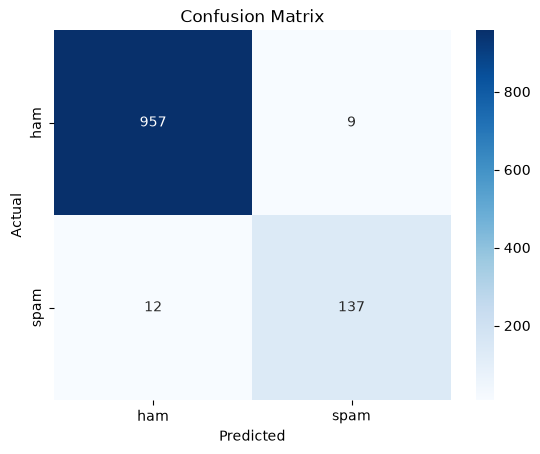

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["ham", "spam"]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ham", "spam"],
    yticklabels=["ham", "spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
results = pd.DataFrame({
    "text": df.loc[X_test.index, "message"].values,
    "actual": y_test.values,
    "predicted": y_pred
})

errors = results[
    results["actual"] != results["predicted"]
]

print("Всего ошибок:", len(errors))

display(errors.head(5))


Всего ошибок: 21


,text,actual,predicted
44,FreeMsg Hey there darling it's been 3 week's n...,spam,ham
78,Did u receive my msg?,ham,spam
93,I'm always on yahoo messenger now. Just send t...,ham,spam
196,ringtoneking 84484,spam,ham
197,.Please charge my mobile when you get up in mo...,ham,spam


In [17]:
for i, (_, row) in enumerate(errors.head(5).iterrows(), start=1):
    print(f"\nОшибка {i}")
    print("Текст:", row["text"])
    print("Реальный класс:", row["actual"])
    print("Предсказание:", row["predicted"])
    print("-" * 50)


Ошибка 1
Текст: FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
Реальный класс: spam
Предсказание: ham
--------------------------------------------------

Ошибка 2
Текст: Did u receive my msg?
Реальный класс: ham
Предсказание: spam
--------------------------------------------------

Ошибка 3
Текст: I'm always on yahoo messenger now. Just send the message to me and i.ll get it you may have to send it in the mobile mode sha but i.ll get it. And will reply.
Реальный класс: ham
Предсказание: spam
--------------------------------------------------

Ошибка 4
Текст: ringtoneking 84484
Реальный класс: spam
Предсказание: ham
--------------------------------------------------

Ошибка 5
Текст: .Please charge my mobile when you get up in morning.
Реальный класс: ham
Предсказание: spam
--------------------------------------------------


In [18]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        min_df=2,
        max_df=0.95,
        max_features=3000
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

pipeline_pred = pipeline.predict(X_test)

print(classification_report(y_test, pipeline_pred))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.94      0.92      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



### Вывод по практической работе №6

В ходе практической работы была реализована система классификации SMS-сообщений на два класса: spam и ham.

Для предобработки текста использовались приведение к нижнему регистру, удаление пунктуации, цифр и стоп-слов, токенизация и стемминг.

Тексты были преобразованы в числовые признаки методом TF-IDF с ограничениями `min_df=2`, `max_df=0.95` и `max_features=3000`.

Для классификации использовалась модель Logistic Regression.

**Результаты:**
- Количество признаков: [вставить результат]
- Accuracy: [вставить]
- Precision (spam): [вставить]
- Recall (spam): [вставить]
- F1-score (spam): [вставить]

Были рассмотрены пять неверно классифицированных сообщений и сформулированы гипотезы о причинах ошибок.

Возможными ограничениями модели являются потеря полезной информации при очистке текста, неоднозначность отдельных слов и недостаточный учёт контекста.

Таким образом, работа демонстрирует основные этапы предобработки текста, векторизации TF-IDF, обучения классификатора и анализа его ошибок.